In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


The dataset contains customer information including demographics, services, and billing details. The target variable is Churn, which indicates whether a customer leaves the company.

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [4]:
df['TotalCharges'] = df['TotalCharges'].astype(str)
df['TotalCharges'] = df['TotalCharges'].replace(" ", np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df = df.dropna()
df = df.drop('customerID', axis=1, errors='ignore')

## Data Cleaning

TotalCharges was converted to numeric. Missing values were removed. 'customerID' was dropped because it does not affect prediction.

In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

## Encoding

All categorical values were converted into numbers using Label Encoding.

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb
from xgboost import XGBClassifier

X = df.drop('Churn', axis=1)
y = df['Churn']

Multiple models are used to identify important features.

In [7]:
rf = RandomForestClassifier()
rf.fit(X, y)
rf.feature_importances_

array([0.02746173, 0.02111565, 0.02243607, 0.01964811, 0.15240107,
       0.00527867, 0.02182609, 0.02513904, 0.04098084, 0.03147346,
       0.02530548, 0.04159407, 0.01755317, 0.01733399, 0.07814542,
       0.02475196, 0.05118601, 0.18166824, 0.19470094])

In [8]:
dt = DecisionTreeClassifier()
dt.fit(X, y)
dt.feature_importances_

array([0.02659906, 0.01885005, 0.01393083, 0.01999161, 0.11530157,
       0.00211046, 0.01517552, 0.02822735, 0.04495827, 0.01081763,
       0.01921004, 0.01758495, 0.01185558, 0.00935653, 0.16930023,
       0.01832864, 0.03931045, 0.19253089, 0.22656032])

In [9]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X, y)
lr.coef_[0]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


array([-2.66554865e-02,  2.34682855e-01,  1.77860712e-02, -1.67604906e-01,
       -5.90244302e-02, -1.01101010e+00,  7.47490039e-02,  2.31709929e-01,
       -2.71248282e-01, -1.43271703e-01, -8.80525677e-02, -2.62391251e-01,
       -3.03116660e-03, -4.07955121e-05, -7.01366347e-01,  3.61584695e-01,
        4.78953584e-02,  2.27891835e-02,  3.05728586e-04])

In [10]:
lgb_model = lgb.LGBMClassifier()
lgb_model.fit(X, y)
lgb_model.feature_importances_

[LightGBM] [Info] Number of positive: 1869, number of negative: 5163
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010005 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 626
[LightGBM] [Info] Number of data points in the train set: 7032, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265785 -> initscore=-1.016114
[LightGBM] [Info] Start training from score -1.016114


array([100,  53,  56,  49, 447,  16,  59,  31,  64,  69,  38,  53,  51,
        54,  98,  79, 157, 834, 692], dtype=int32)

In [11]:
xgb = XGBClassifier()
xgb.fit(X, y)
xgb.feature_importances_

array([0.01547056, 0.0200162 , 0.01477213, 0.0172257 , 0.02831579,
       0.03544062, 0.01899416, 0.20156468, 0.08264321, 0.02144713,
       0.01563482, 0.05338779, 0.01817878, 0.02403162, 0.3534939 ,
       0.02085151, 0.01846348, 0.02041437, 0.01965359], dtype=float32)

## SHAP Explanation

SHAP explains how each feature contributes to predictions. Positive values increase churn probability, while negative values decrease it.

 98%|===================| 6885/7032 [00:31<00:00]       

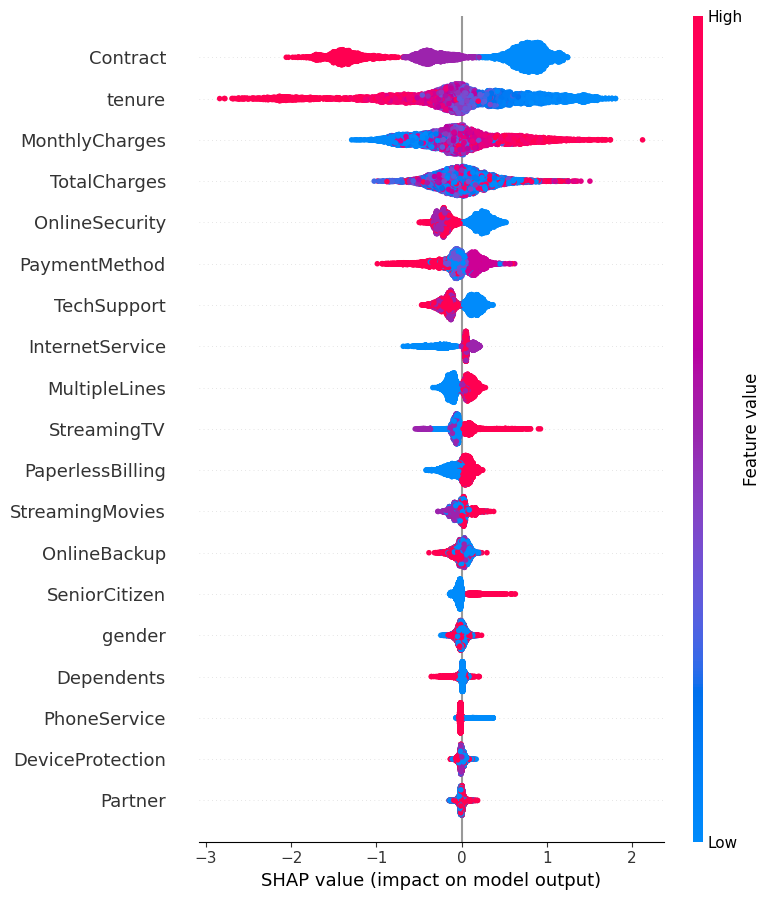

In [12]:
import shap

explainer = shap.Explainer(lgb_model, X)
shap_values = explainer(X, check_additivity=False)

shap.summary_plot(shap_values, X)

In [13]:
df['Monthly_to_Total'] = df['MonthlyCharges'] / (df['TotalCharges'] + 1)
df['Tenure_Monthly'] = df['tenure'] * df['MonthlyCharges']
df['Charges_per_tenure'] = df['TotalCharges'] / (df['tenure'] + 1)

## Feature Engineering

New features were created to better represent customer behavior and improve prediction performance.

In [14]:
X_new = df.drop('Churn', axis=1)
y_new = df['Churn']

lgb_model.fit(X_new, y_new)

[LightGBM] [Info] Number of positive: 1869, number of negative: 5163
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000739 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1391
[LightGBM] [Info] Number of data points in the train set: 7032, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265785 -> initscore=-1.016114
[LightGBM] [Info] Start training from score -1.016114


LGBMClassifier()

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_new)

## Standardization

Data was scaled to improve model performance.

In [16]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3)
df['Cluster'] = kmeans.fit_predict(X_scaled)

## K-Means Clustering

A new feature "Cluster" was created to group similar customers.

In [17]:
df.to_csv("final_dataset.csv", index=False)

## Conclusion

Feature engineering improved the dataset by creating new features, selecting important features, and adding clustering information.  
The final dataset is ready for further machine learning tasks.